### 1. SETUP DEPENDENCIES & MLFLOW TRACKING

In [15]:
import os
import re
import warnings
import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
import joblib
import mlflow
from datetime import datetime

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

DATA_PATH = '../data'
MODELS_PATH = '../models'
OUTPUT_PATH = '../output'
for path in [MODELS_PATH, OUTPUT_PATH]:
    os.makedirs(path, exist_ok=True)

mlflow.set_tracking_uri("sqlite:///mlruns_manual.db")
NAMA_EKSPERIMEN_FORECAST = "AGRIVA_Forecasting_Apex_Final"
mlflow.set_experiment(NAMA_EKSPERIMEN_FORECAST)

print(f"[STEP 1] Environment setup completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

2026/06/09 12:06:19 INFO mlflow.tracking.fluent: Experiment with name 'AGRIVA_Forecasting_Apex_Final' does not exist. Creating a new experiment.


[STEP 1] Environment setup completed at: 2026-06-09 12:06:19


### 2. DATA TRANSFORMATION & TEMPORAL SPLITTING

In [16]:
data_path = os.path.join(DATA_PATH, 'data_master_clustered_final.csv')
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df['Year'] = df['date'].dt.year
df['Month'] = df['date'].dt.month
df['Day'] = df['date'].dt.day

def hitung_dasarian(hari):
    if hari <= 10: return 1
    elif hari <= 20: return 2
    else: return 3

df['Dasarian'] = df['Day'].apply(hitung_dasarian)

fitur_wajib = [
    'Rainfall', 'SPI - 3 months', 'Temperature', 'Water Satisfaction Index (WSI)',
    'Solar Radiation', 'Soil Moisture (gapfilled historical time series)', 'FPAR', 'FPAR - zscore'
]

df_dasarian = df.groupby(['Cluster', 'Year', 'Month', 'Dasarian'])[fitur_wajib].mean().reset_index()
df_dasarian = df_dasarian.sort_values(['Cluster', 'Year', 'Month', 'Dasarian']).reset_index(drop=True)

df_dasarian['Split_Stage'] = 'Train'
df_dasarian.loc[df_dasarian['Year'] == 2024, 'Split_Stage'] = 'Validation'
df_dasarian.loc[df_dasarian['Year'] >= 2025, 'Split_Stage'] = 'Test'

print("[STEP 2] Dasarian transformation and temporal splitting (Train: <=2023, Val: 2024, Test: 2025-2026) completed.")

[STEP 2] Dasarian transformation and temporal splitting (Train: <=2023, Val: 2024, Test: 2025-2026) completed.


### 3. TIME SERIES EXPLORATORY DATA ANALYSIS (EDA)

[STEP 3] Menjalankan Time Series EDA (Seasonal Decomposition, ACF, PACF, Lag Plot)


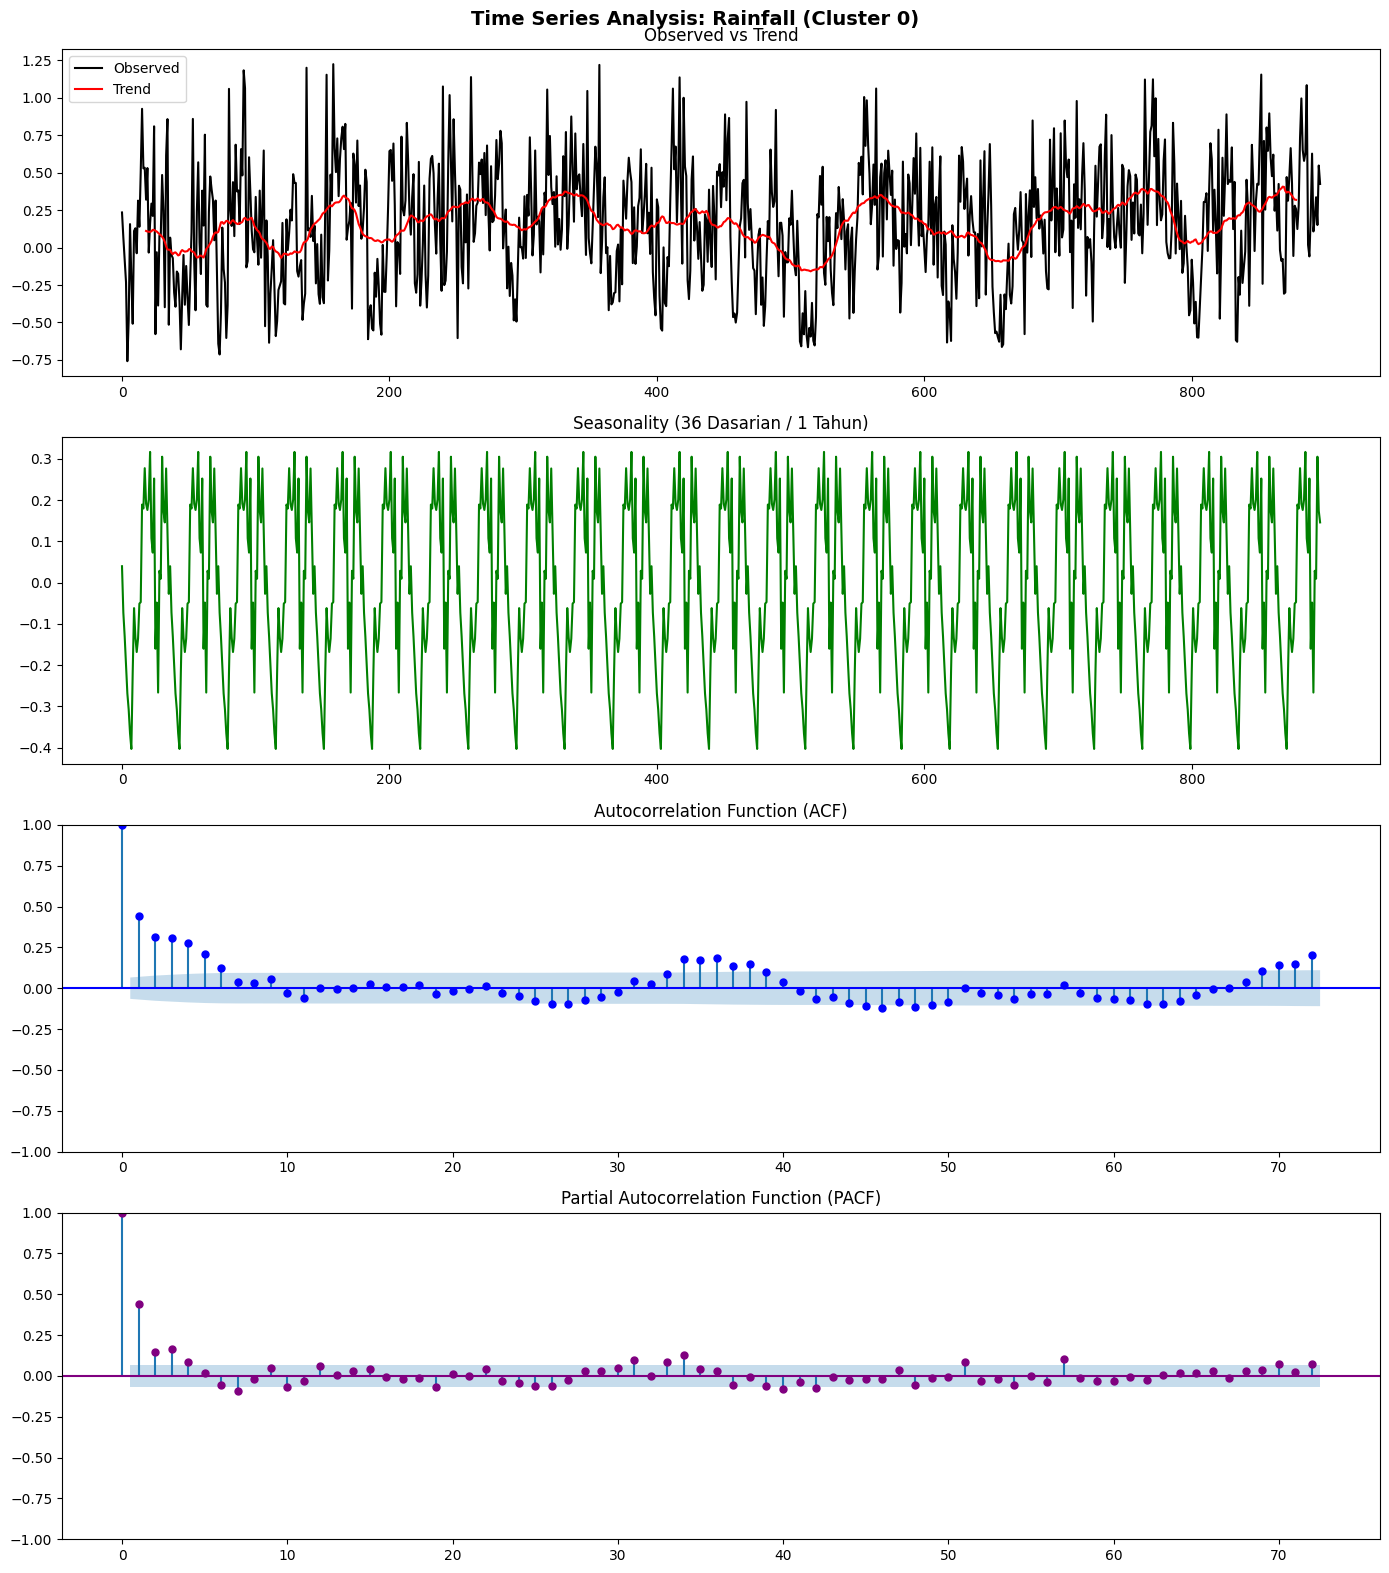

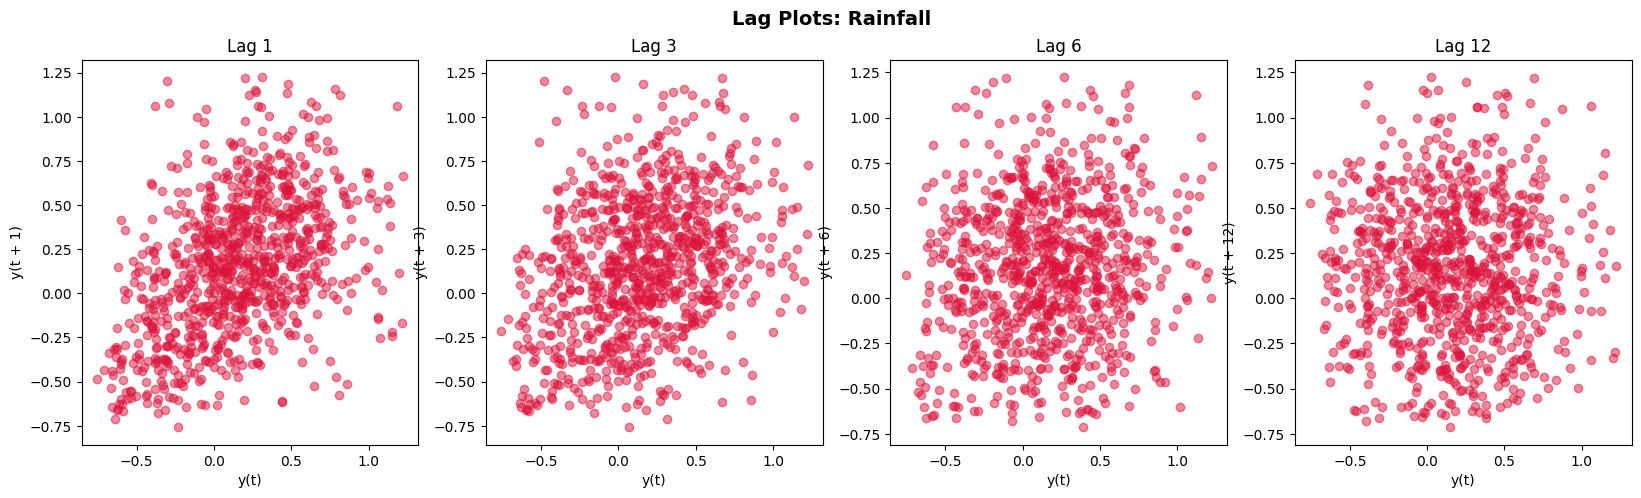

[STEP 3] Visualisasi EDA deret waktu berhasil disimpan.


In [17]:
print("[STEP 3] Menjalankan Time Series EDA (Seasonal Decomposition, ACF, PACF, Lag Plot)")

cluster_target = 0
fitur_target = 'Rainfall'

df_eda = df_dasarian[df_dasarian['Cluster'] == cluster_target].copy()
ts_data = df_eda[fitur_target].values

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle(f'Time Series Analysis: {fitur_target} (Cluster {cluster_target})', fontsize=14, fontweight='bold')

decomposition = seasonal_decompose(ts_data, model='additive', period=36)
axes[0].plot(decomposition.observed, label='Observed', color='black')
axes[0].plot(decomposition.trend, label='Trend', color='red')
axes[0].set_title('Observed vs Trend')
axes[0].legend()

axes[1].plot(decomposition.seasonal, color='green')
axes[1].set_title('Seasonality (36 Dasarian / 1 Tahun)')

plot_acf(ts_data, lags=72, ax=axes[2], color='blue')
axes[2].set_title('Autocorrelation Function (ACF)')

plot_pacf(ts_data, lags=72, ax=axes[3], color='purple')
axes[3].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
eda_path = os.path.join(OUTPUT_PATH, '01_ts_eda_decomposition_acf.png')
plt.savefig(eda_path)
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(f'Lag Plots: {fitur_target}', fontsize=14, fontweight='bold')
for i, lag in enumerate([1, 3, 6, 12]):
    pd.plotting.lag_plot(df_eda[fitur_target], lag=lag, ax=axes[i], c='crimson', alpha=0.5)
    axes[i].set_title(f'Lag {lag}')
    
lag_path = os.path.join(OUTPUT_PATH, '02_ts_eda_lag_plots.png')
plt.savefig(lag_path)
plt.show()

if mlflow.active_run(): mlflow.end_run()
with mlflow.start_run(run_name="Time_Series_EDA"):
    mlflow.log_artifact(eda_path)
    mlflow.log_artifact(lag_path)

print("[STEP 3] Visualisasi EDA deret waktu berhasil disimpan.")

### 4. MULTIVARIATE LAG FEATURE ENGINEERING

In [18]:
TARGET_LAGS = [1, 2, 3, 6, 12]
cluster_ts_data = {}

for cluster_id in sorted(df_dasarian['Cluster'].unique()):
    df_c = df_dasarian[df_dasarian['Cluster'] == cluster_id].copy().reset_index(drop=True)
    
    for feature in fitur_wajib:
        for lag in TARGET_LAGS:
            df_c[f'{feature}_lag_{lag}'] = df_c[feature].shift(lag)
            
    df_c = df_c.dropna().reset_index(drop=True)
    cluster_ts_data[int(cluster_id)] = df_c

print(f"[STEP 4] Lag features {TARGET_LAGS} generation completed.")

[STEP 4] Lag features [1, 2, 3, 6, 12] generation completed.


### 5. APEX HETEROGENEOUS ENGINE (3-SCENARIO COMPETITION)

In [19]:
best_forecasters_models = {}

print("[STEP 5] Memulai Arena Kompetisi 3 Skenario (Apex Engine)")

for cluster_id in sorted(cluster_ts_data.keys()):
    print(f"\n>>> PROCESSING CLUSTER {cluster_id} <<<")
    df_c = cluster_ts_data[cluster_id]
    
    X_cols = [col for col in df_c.columns if '_lag_' in col]
    y_cols = fitur_wajib
    
    X_train = df_c[df_c['Split_Stage'] == 'Train'][X_cols]
    y_train = df_c[df_c['Split_Stage'] == 'Train'][y_cols]
    X_val = df_c[df_c['Split_Stage'] == 'Validation'][X_cols]
    y_val = df_c[df_c['Split_Stage'] == 'Validation'][y_cols]
    X_test = df_c[df_c['Split_Stage'] == 'Test'][X_cols]
    y_test = df_c[df_c['Split_Stage'] == 'Test'][y_cols]
    
    X_train_val = pd.concat([X_train, X_val]).reset_index(drop=True)
    y_train_val = pd.concat([y_train, y_val]).reset_index(drop=True)
    
    skenario_results = {}

    print("  -> Run Skenario 1: XGBoost Baseline")
    model_s1 = MultiOutputRegressor(xgb.XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1))
    model_s1.fit(X_train, y_train)
    skenario_results['S1_XGB_Baseline'] = {'model': model_s1, 'mae': mean_absolute_error(y_val, model_s1.predict(X_val)), 'algo': 'XGBoost'}

    print("  -> Run Skenario 2: LightGBM Deep Tuning")
    def obj_lgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 150, 400),
            'max_depth': trial.suggest_int('max_depth', 4, 12),
            'num_leaves': trial.suggest_int('num_leaves', 20, 150),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'random_state': 42, 'n_jobs': -1, 'verbose': -1
        }
        m = MultiOutputRegressor(LGBMRegressor(**params))
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))
        
    study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study_lgb.optimize(obj_lgb, n_trials=30)
    model_s2 = MultiOutputRegressor(LGBMRegressor(**study_lgb.best_params, random_state=42, verbose=-1))
    model_s2.fit(X_train, y_train)
    skenario_results['S2_LGBM_Tuned'] = {'model': model_s2, 'mae': study_lgb.best_value, 'algo': 'LightGBM', 'params': study_lgb.best_params}

    print("  -> Run Skenario 3: XGBoost Deep Tuning")
    def obj_xgb(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 150, 400),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.1, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 1.0),
            'random_state': 42, 'n_jobs': -1
        }
        m = MultiOutputRegressor(xgb.XGBRegressor(**params))
        m.fit(X_train, y_train)
        return mean_absolute_error(y_val, m.predict(X_val))

    study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
    study_xgb.optimize(obj_xgb, n_trials=30)
    model_s3 = MultiOutputRegressor(xgb.XGBRegressor(**study_xgb.best_params, random_state=42, n_jobs=-1))
    model_s3.fit(X_train, y_train)
    skenario_results['S3_XGB_Tuned'] = {'model': model_s3, 'mae': study_xgb.best_value, 'algo': 'XGBoost', 'params': study_xgb.best_params}

    pemenang = min(skenario_results, key=lambda k: skenario_results[k]['mae'])
    print(f"  [WINNER] {pemenang} (MAE: {skenario_results[pemenang]['mae']:.4f})")
    
    final_model = skenario_results[pemenang]['model']
    final_model.fit(X_train_val, y_train_val)
    
    if mlflow.active_run(): mlflow.end_run()
    with mlflow.start_run(run_name=f"Cluster_{cluster_id}_{pemenang}_Apex"):
        mlflow.log_param("Winning_Algorithm", skenario_results[pemenang]['algo'])
        mlflow.log_param("Winning_Scenario", pemenang)
        mlflow.log_metric("Validation_MAE_Winner", skenario_results[pemenang]['mae'])
        if 'params' in skenario_results[pemenang]:
            mlflow.log_params(skenario_results[pemenang]['params'])

    best_forecasters_models[cluster_id] = {
        'model': final_model, 'features': y_cols, 'lag_columns': X_cols,
        'X_test': X_test, 'y_test': y_test
    }

[STEP 5] Memulai Arena Kompetisi 3 Skenario (Apex Engine)

>>> PROCESSING CLUSTER 0 <<<
  -> Run Skenario 1: XGBoost Baseline
  -> Run Skenario 2: LightGBM Deep Tuning
  -> Run Skenario 3: XGBoost Deep Tuning
  [WINNER] S3_XGB_Tuned (MAE: 0.1523)

>>> PROCESSING CLUSTER 1 <<<
  -> Run Skenario 1: XGBoost Baseline
  -> Run Skenario 2: LightGBM Deep Tuning
  -> Run Skenario 3: XGBoost Deep Tuning
  [WINNER] S2_LGBM_Tuned (MAE: 0.1507)

>>> PROCESSING CLUSTER 2 <<<
  -> Run Skenario 1: XGBoost Baseline
  -> Run Skenario 2: LightGBM Deep Tuning
  -> Run Skenario 3: XGBoost Deep Tuning
  [WINNER] S3_XGB_Tuned (MAE: 0.1600)


### 6. TEST EVALUATION & RESIDUAL ANALYSIS DASHBOARD

In [20]:
print("[STEP 6] Test Evaluation & Residual Analysis")

if mlflow.active_run(): mlflow.end_run()

for cluster_id, model_pack in best_forecasters_models.items():
    X_test, y_test = model_pack['X_test'], model_pack['y_test']
    model, features = model_pack['model'], model_pack['features']
    pred_test = model.predict(X_test)
    
    print(f"\n--- EVALUATION CLUSTER {cluster_id} ---")
    with mlflow.start_run(run_name=f"Cluster_{cluster_id}_Test_Eval"):
        for idx, feat_name in enumerate(features):
            y_true = y_test.iloc[:, idx]
            y_pred = pred_test[:, idx]
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            mae = mean_absolute_error(y_true, y_pred)
            r2 = r2_score(y_true, y_pred)
            print(f"Target: {feat_name:.<45} RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
            mlflow.log_metric(f"Test_{re.sub(r'[^a-zA-Z0-9]', '', feat_name)}_RMSE", rmse)
        
        fig, axes = plt.subplots(4, 4, figsize=(20, 16))
        fig.suptitle(f'Actual vs Forecast & Residuals (Test 2025-2026) - Cluster {cluster_id}', fontsize=16, fontweight='bold', y=0.92)
        
        for idx, feat_name in enumerate(features):
            y_true = y_test.iloc[:, idx]
            y_pred = pred_test[:, idx]
            residuals = y_true - y_pred
            
            row = idx // 2
            col_base = (idx % 2) * 2
            
            # Plot Actual vs Pred
            axes[row, col_base].plot(range(len(y_test)), y_true, label='Actual', color='black')
            axes[row, col_base].plot(range(len(y_test)), y_pred, label='Prediction', color='crimson', linestyle='--')
            axes[row, col_base].set_title(f'{feat_name} (Forecast)')
            
            # Plot Residual
            sns.scatterplot(x=y_pred, y=residuals, ax=axes[row, col_base+1], color='blue', alpha=0.6)
            axes[row, col_base+1].axhline(0, color='red', linestyle='--')
            axes[row, col_base+1].set_title(f'{feat_name} (Residual)')
                
        plt.subplots_adjust(hspace=0.4, wspace=0.3)
        chart_path = os.path.join(OUTPUT_PATH, f'03_eval_residual_cluster_{cluster_id}.png')
        plt.savefig(chart_path, bbox_inches='tight')
        plt.close()
        mlflow.log_artifact(chart_path)

[STEP 6] Test Evaluation & Residual Analysis

--- EVALUATION CLUSTER 0 ---
Target: Rainfall..................................... RMSE: 0.3598 | MAE: 0.2951 | R2: -0.0686
Target: SPI - 3 months............................... RMSE: 0.2153 | MAE: 0.1609 | R2: 0.5232
Target: Temperature.................................. RMSE: 0.1031 | MAE: 0.0819 | R2: 0.2505
Target: Water Satisfaction Index (WSI)............... RMSE: 0.0180 | MAE: 0.0130 | R2: 0.9674
Target: Solar Radiation.............................. RMSE: 0.4840 | MAE: 0.3862 | R2: 0.2535
Target: Soil Moisture (gapfilled historical time series) RMSE: 0.0890 | MAE: 0.0710 | R2: 0.5206
Target: FPAR......................................... RMSE: 0.0772 | MAE: 0.0615 | R2: 0.9539
Target: FPAR - zscore................................ RMSE: 0.1467 | MAE: 0.1154 | R2: 0.8824

--- EVALUATION CLUSTER 1 ---
Target: Rainfall..................................... RMSE: 0.3037 | MAE: 0.2605 | R2: 0.4051
Target: SPI - 3 months.......................

### 7. RECURSIVE FORECASTING ENGINE (FULL 2026 INTEGRATION

In [21]:
print("[STEP 7] Menjalankan Mesin Rekursi Proyeksi 2026 (Integrasi Aktual Jan-Mar & Proyeksi Apr-Des)")

full_2026_projections = []

for cluster_id, model_pack in best_forecasters_models.items():
    df_c = cluster_ts_data[cluster_id]
    model = model_pack['model']
    lag_cols = model_pack['lag_columns']
    
    # Memfilter data historis hanya sampai Maret 2026 untuk inisialisasi buffer
    df_historical = df_c[(df_c['Year'] < 2026) | ((df_c['Year'] == 2026) & (df_c['Month'] <= 3))].sort_values(['Year', 'Month', 'Dasarian'])
    
    if len(df_historical) < 12:
        raise ValueError(f"Data historis Klaster {cluster_id} tidak mencukupi untuk buffer memori lag 12.")
        
    # 1. Ekstraksi Data Aktual Q1 (Januari - Maret 2026) ke dalam output final
    actual_q1_2026 = df_historical[df_historical['Year'] == 2026].copy()
    for _, row in actual_q1_2026.iterrows():
        row_data = {'Cluster': cluster_id, 'Year': 2026, 'Month': int(row['Month']), 'Dasarian': int(row['Dasarian'])}
        for feat in fitur_wajib:
            row_data[feat] = row[feat]
        row_data['Data_Type'] = 'Actual'
        full_2026_projections.append(row_data)

    # 2. Persiapan Buffer Memori untuk peramalan selanjutnya
    history_buffer = df_historical.tail(12)[fitur_wajib].values.copy()
    
    # 3. Proyeksi eksklusif untuk Bulan 4 hingga 12 Tahun 2026
    for month in range(4, 13):
        for dasarian in [1, 2, 3]:
            input_dict = {}
            for f_idx, feat in enumerate(fitur_wajib):
                for lag in TARGET_LAGS:
                    input_dict[f'{feat}_lag_{lag}'] = history_buffer[-lag, f_idx]
            
            input_df = pd.DataFrame([input_dict], columns=lag_cols)
            simultaneous_forecast = model.predict(input_df)[0]
            
            row_proj = {'Cluster': cluster_id, 'Year': 2026, 'Month': month, 'Dasarian': dasarian}
            for f_idx, feat_name in enumerate(fitur_wajib):
                row_proj[feat_name] = simultaneous_forecast[f_idx]
            row_proj['Data_Type'] = 'Forecast'
            
            full_2026_projections.append(row_proj)
            
            # Update buffer memori bergeser
            history_buffer = np.roll(history_buffer, -1, axis=0) 
            history_buffer[-1] = simultaneous_forecast

df_final_2026 = pd.DataFrame(full_2026_projections)

# Mengganti nama file keluaran agar lebih representatif
output_file_csv = os.path.join(DATA_PATH, 'hasil_proyeksi_forecasting_full_2026.csv')
df_final_2026.to_csv(output_file_csv, index=False)

print(f"[STEP 7] Integrasi data 2026 (36 Dasarian) selesai. Disimpan di: {output_file_csv}")

[STEP 7] Menjalankan Mesin Rekursi Proyeksi 2026 (Integrasi Aktual Jan-Mar & Proyeksi Apr-Des)
[STEP 7] Integrasi data 2026 (36 Dasarian) selesai. Disimpan di: ../data\hasil_proyeksi_forecasting_full_2026.csv


### 8. FINAL EXPORT & MLFLOW BUNDLING

In [22]:
print("[STEP 8] Mengunci File Master Model")

if mlflow.active_run(): mlflow.end_run()

master_bundle = {}
for cluster_id, model_pack in best_forecasters_models.items():
    master_bundle[cluster_id] = {
        'forecaster_object': model_pack['model'],
        'lag_features_schema': model_pack['lag_columns'],
        'target_features_schema': model_pack['features'],
        'timestamp_serialized': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

master_path = os.path.join(MODELS_PATH, "agriva_master_forecasting.pkl")
joblib.dump(master_bundle, master_path)

with mlflow.start_run(run_name="AGRIVA_FORECAST_DEPLOYMENT_BUNDLE"):
    mlflow.log_artifact(master_path)
    mlflow.log_artifact(output_file_csv)

file_size_mb = os.path.getsize(master_path) / (1024 * 1024)
print(f"[STEP 8] Model berhasil disimpan ke: {master_path} ({file_size_mb:.2f} MB)")

[STEP 8] Mengunci File Master Model
[STEP 8] Model berhasil disimpan ke: ../models\agriva_master_forecasting.pkl (14.34 MB)


### 9. FINAL FORECASTING VISUALIZATION DASHBOARD (2026 TIMELINE)

[EVALUASI BUKTI] Menghasilkan Grafik Overlap Actual vs Prediction (Format Estetis)

Generating Overlap Charts for Cluster 0 using XGBRegressor...


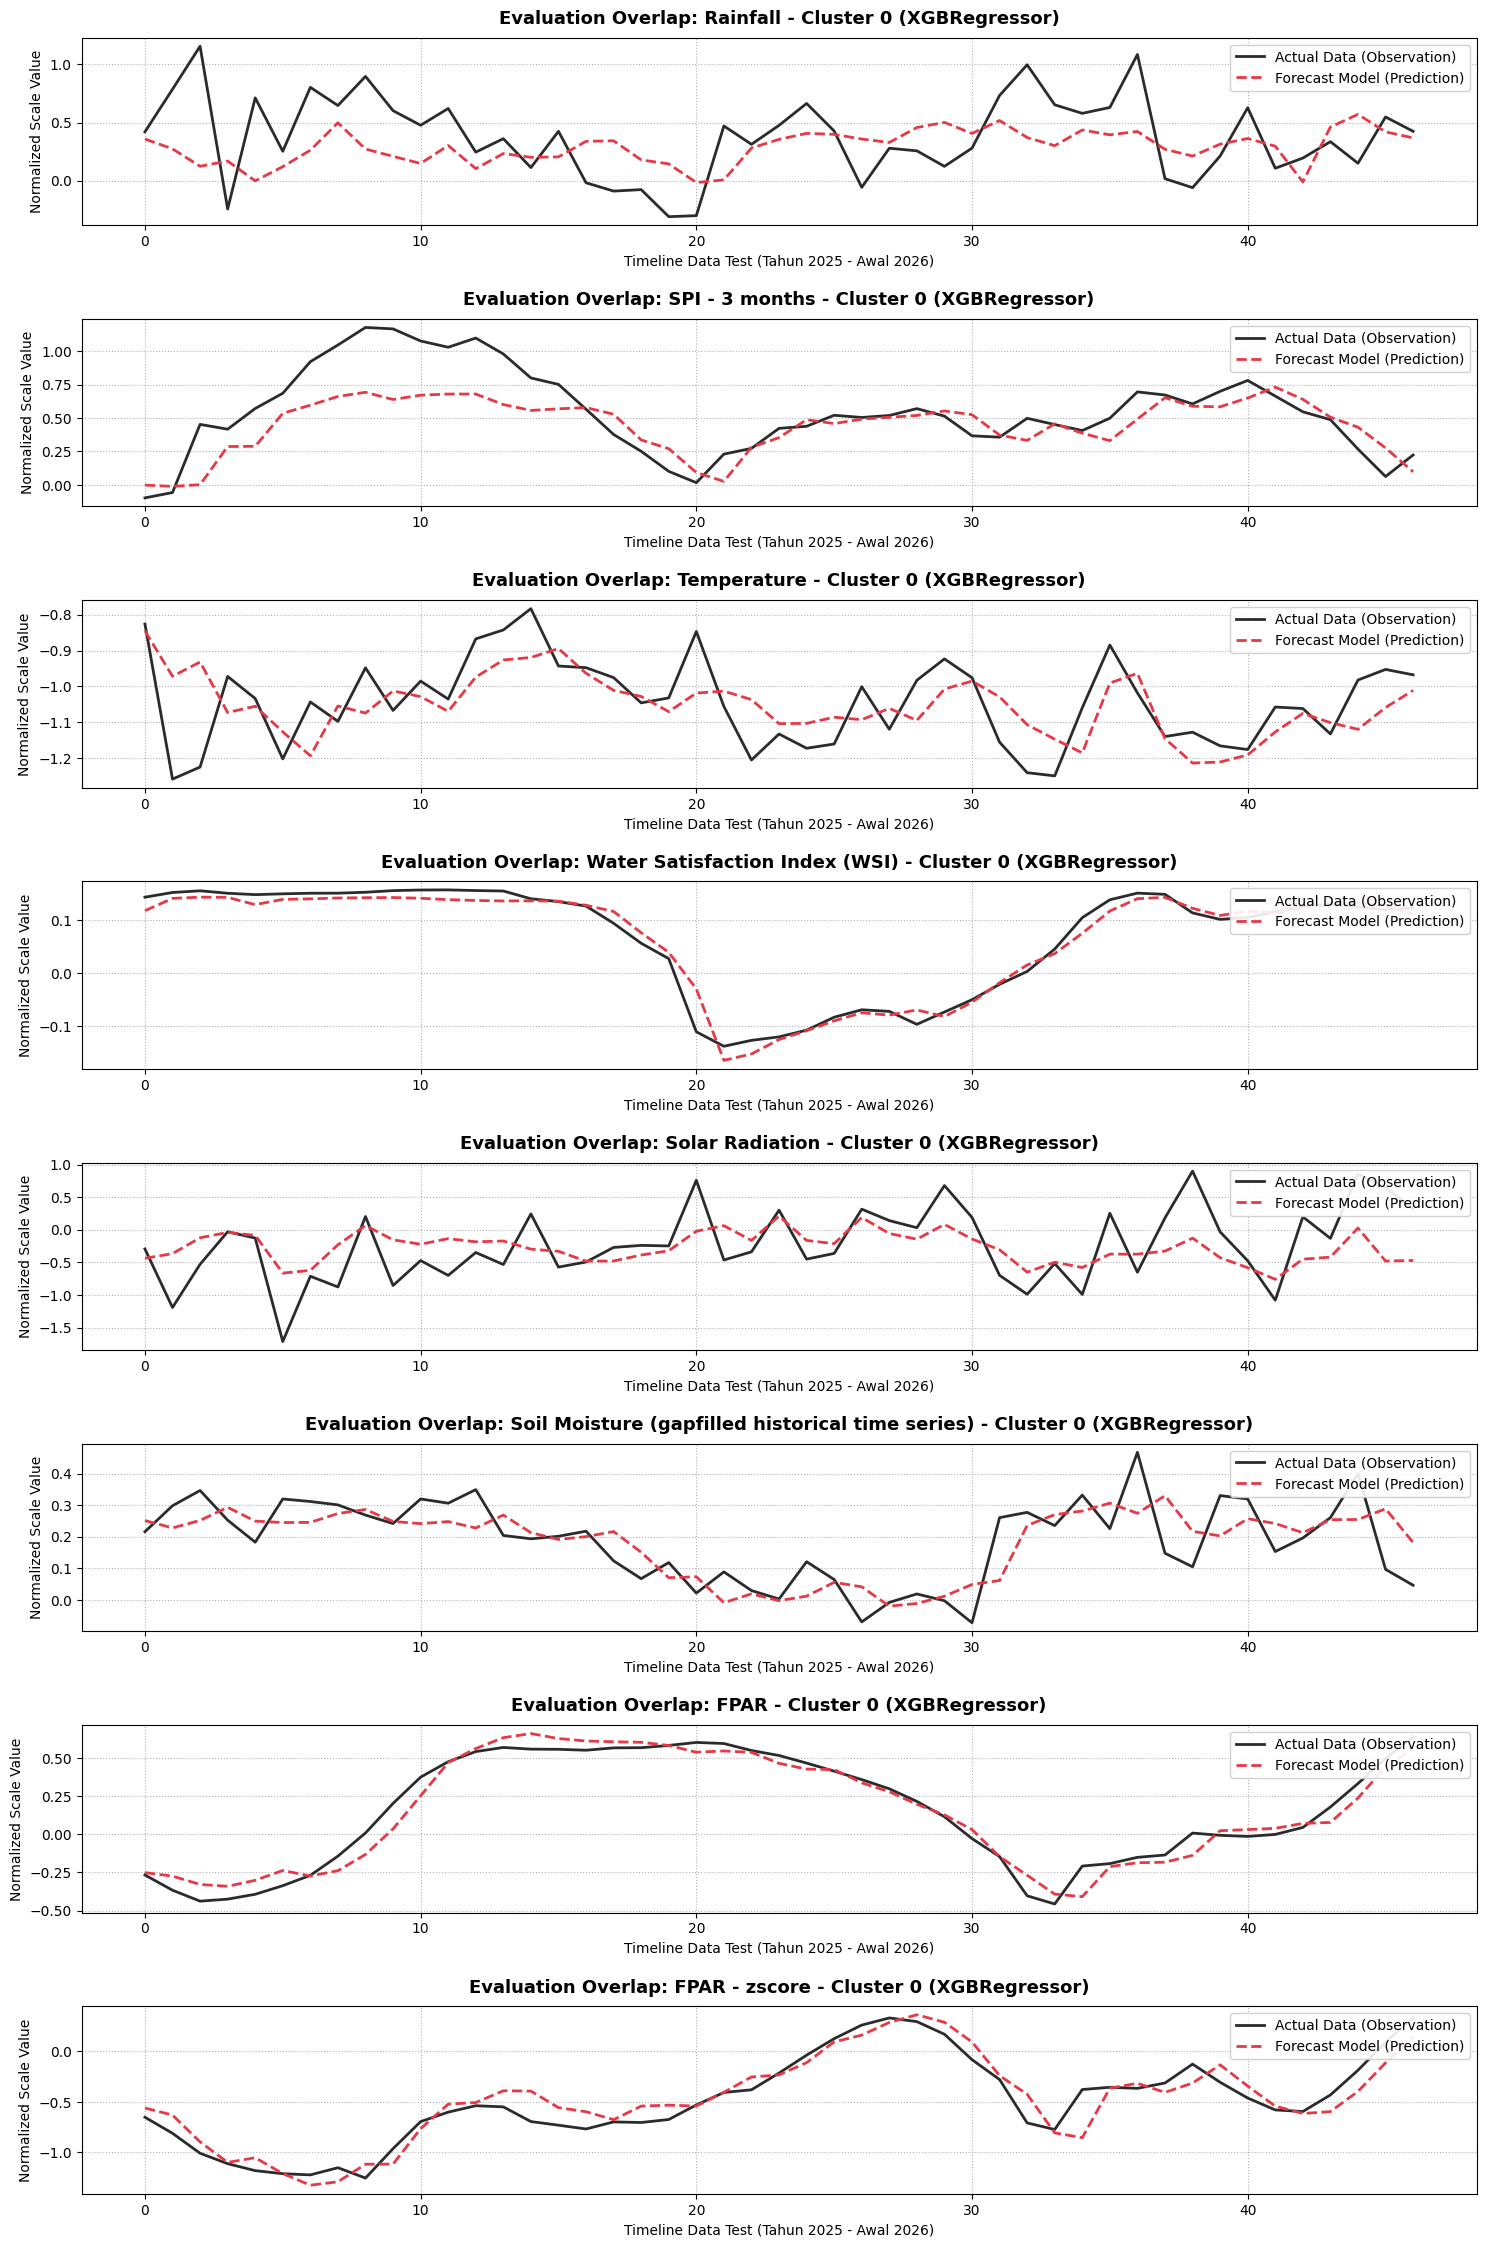


Generating Overlap Charts for Cluster 1 using LGBMRegressor...


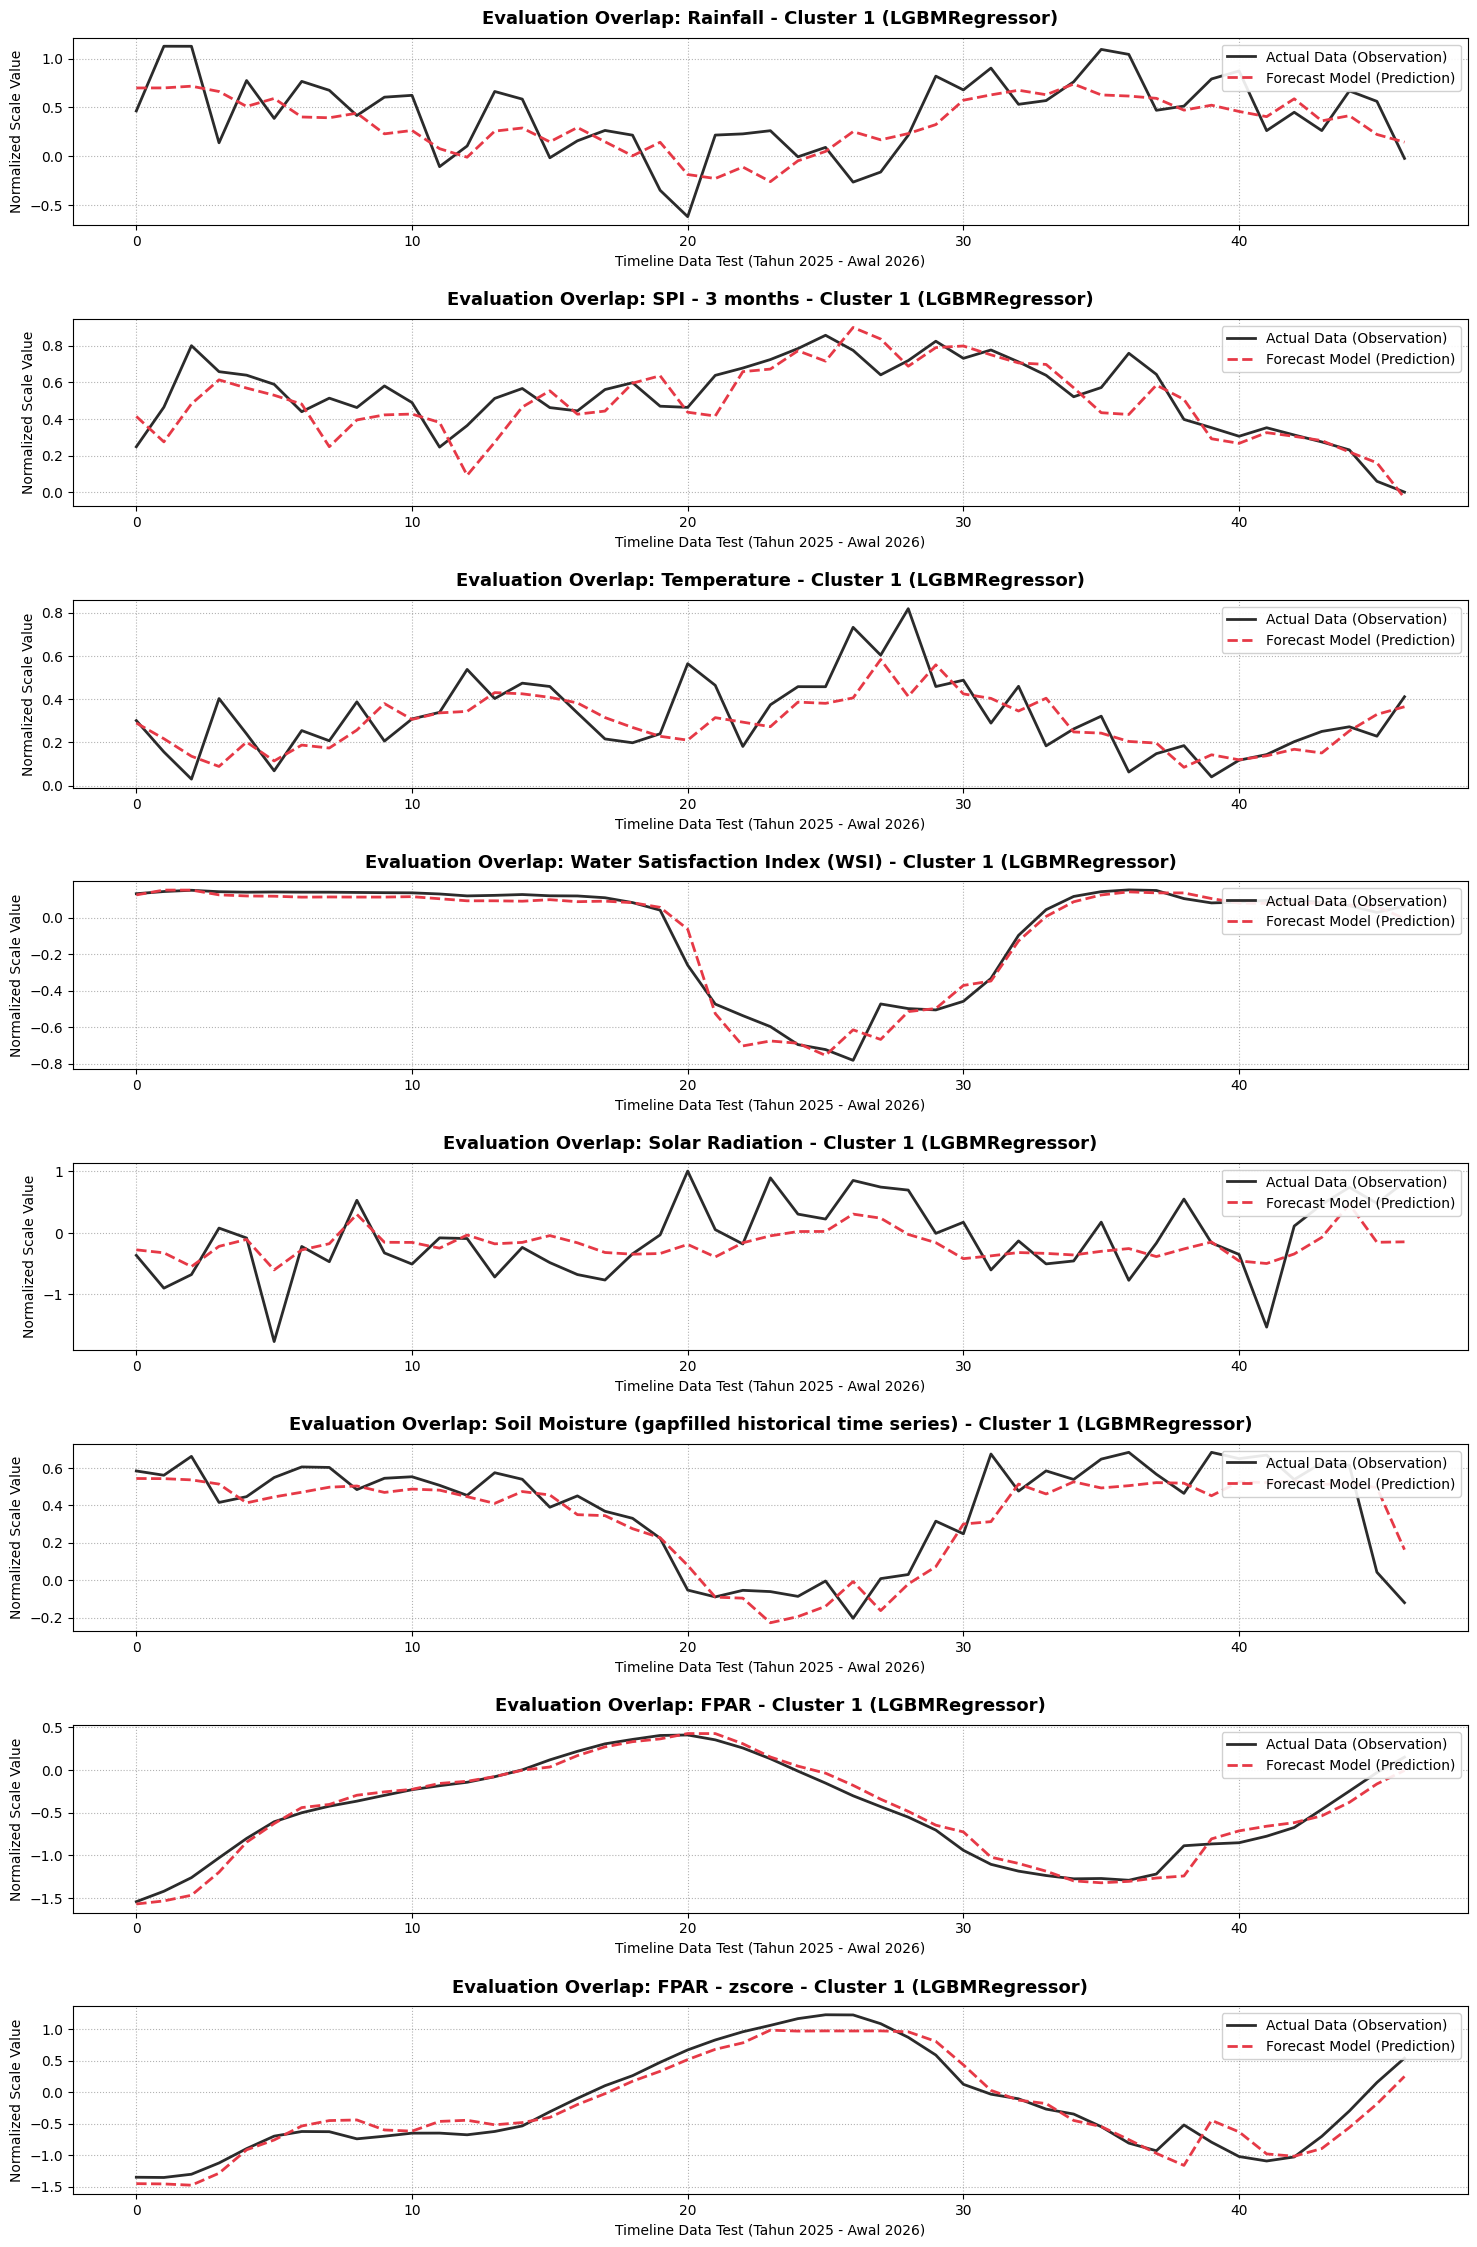


Generating Overlap Charts for Cluster 2 using XGBRegressor...


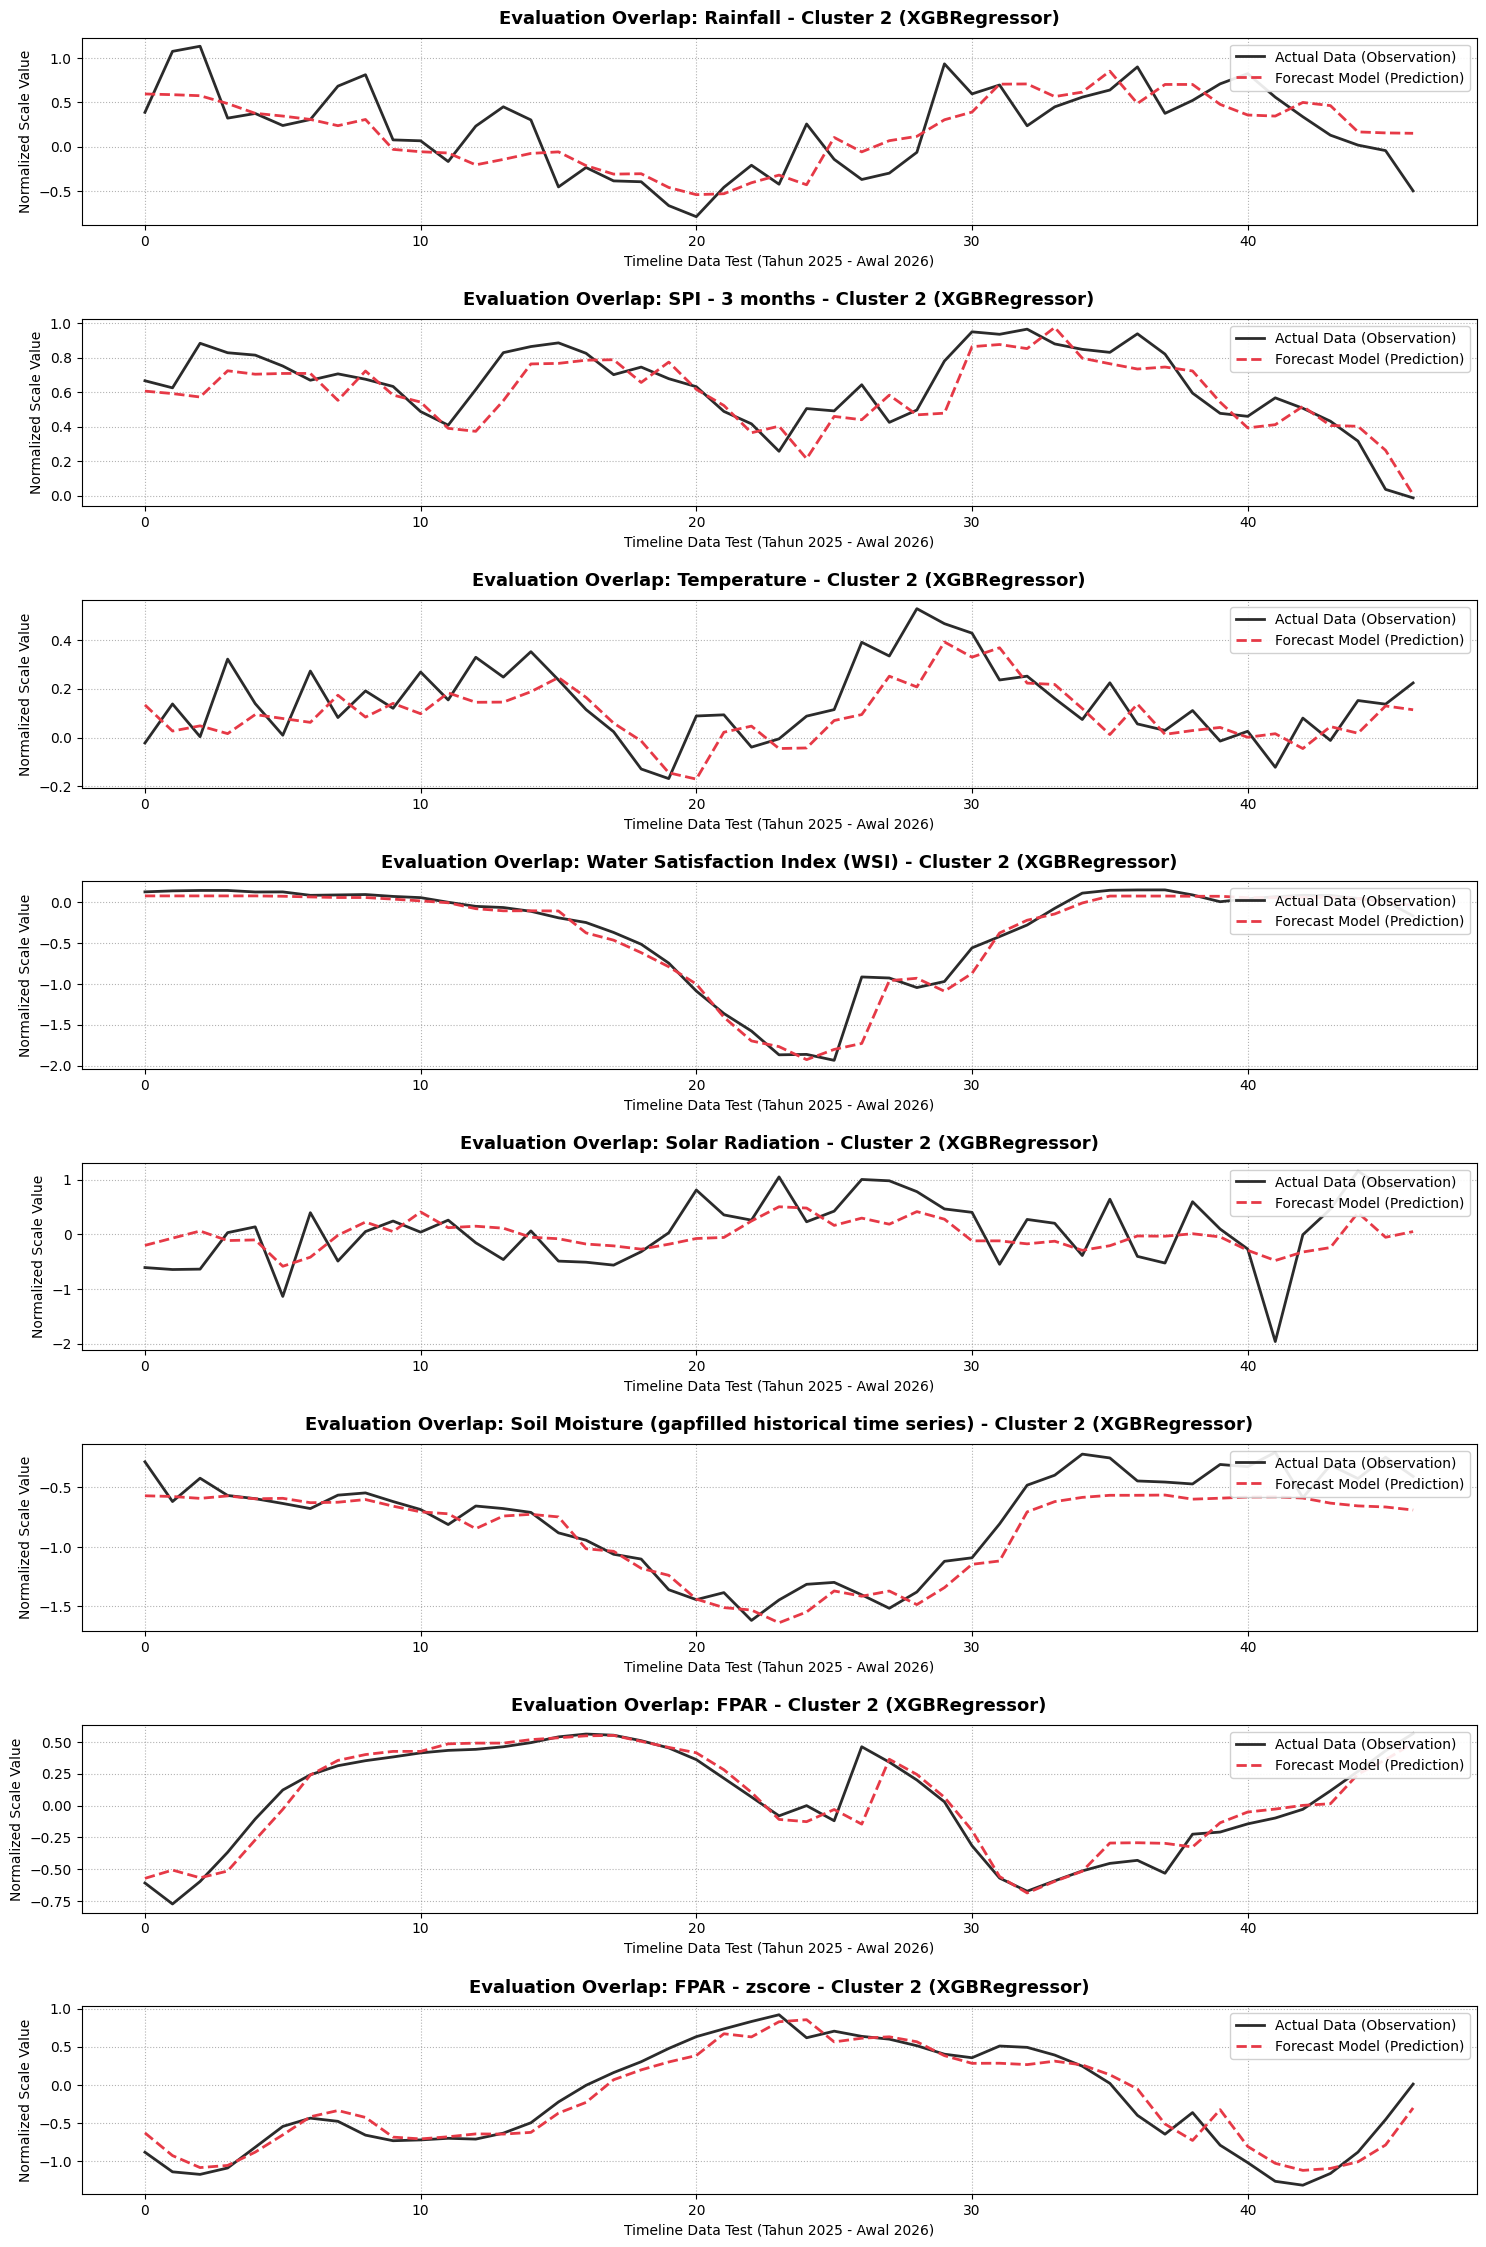


[SELESAI] Grafik bukti overlap berhasil di-render!


In [26]:
# CELL EKSKLUSIF: VISUALISASI BUKTI OVERLAP (ACTUAL VS PREDICTION) PADA DATA TEST
import os
import matplotlib.pyplot as plt

print("[EVALUASI BUKTI] Menghasilkan Grafik Overlap Actual vs Prediction (Format Estetis)")

for cluster_id, model_pack in best_forecasters_models.items():
    y_test = model_pack['y_test']
    model = model_pack['model']
    features = model_pack['features']
    X_test = model_pack['X_test']
    
    # Memerintahkan mesin untuk menebak data test
    pred_test = model.predict(X_test)
    
    # Menarik nama algoritma (XGBoost/LightGBM)
    algo_name = model.estimator.__class__.__name__

    # Membuat canvas memanjang (8 baris x 1 kolom)
    fig, axes = plt.subplots(8, 1, figsize=(18, 28))
    fig.subplots_adjust(hspace=0.5)

    for idx, feat in enumerate(features):
        ax = axes[idx]
        
        # Plot Garis Hitam (Data Aktual Kunci Jawaban)
        ax.plot(range(len(y_test)), y_test.iloc[:, idx], 
                label='Actual Data (Observation)', color='#2b2b2b', linewidth=2)
        
        # Plot Garis Merah (Tebakan Mesin)
        ax.plot(range(len(y_test)), pred_test[:, idx], 
                label='Forecast Model (Prediction)', color='#e63946', linestyle='--', linewidth=2)
        
        # Kustomisasi Estetika
        ax.set_title(f'Evaluation Overlap: {feat} - Cluster {cluster_id} ({algo_name})', 
                     fontsize=13, fontweight='bold', pad=10)
        ax.set_ylabel('Normalized Scale Value', fontsize=10)
        ax.set_xlabel('Timeline Data Test (Tahun 2025 - Awal 2026)', fontsize=10)
        
        # Grid samar
        ax.grid(True, linestyle=':', alpha=0.6, color='gray')
        
        # Legend (Keterangan)
        ax.legend(loc='upper right', fontsize=10, framealpha=0.9)

    chart_path = os.path.join(OUTPUT_PATH, f'05_overlap_proof_cluster_{cluster_id}.png')
    plt.savefig(chart_path, bbox_inches='tight', dpi=300)
    
    print(f"\nGenerating Overlap Charts for Cluster {cluster_id} using {algo_name}...")
    plt.show()
    plt.close()

print("\n[SELESAI] Grafik bukti overlap berhasil di-render!")